      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

--- Simple Linear Regression ---
Coefficient : 0.0465
Intercept   : 7.1196
MSE         : 10.2047
R2 Score    : 0.6767

--- Multiple Linear Regression ---
TV Coefficient: 0.0447
Radio Coefficient: 0.1892
Newspaper Coefficient: 0.0028
Intercept : 2.9791
MSE       : 3.1741
R2 Score  : 0.8994


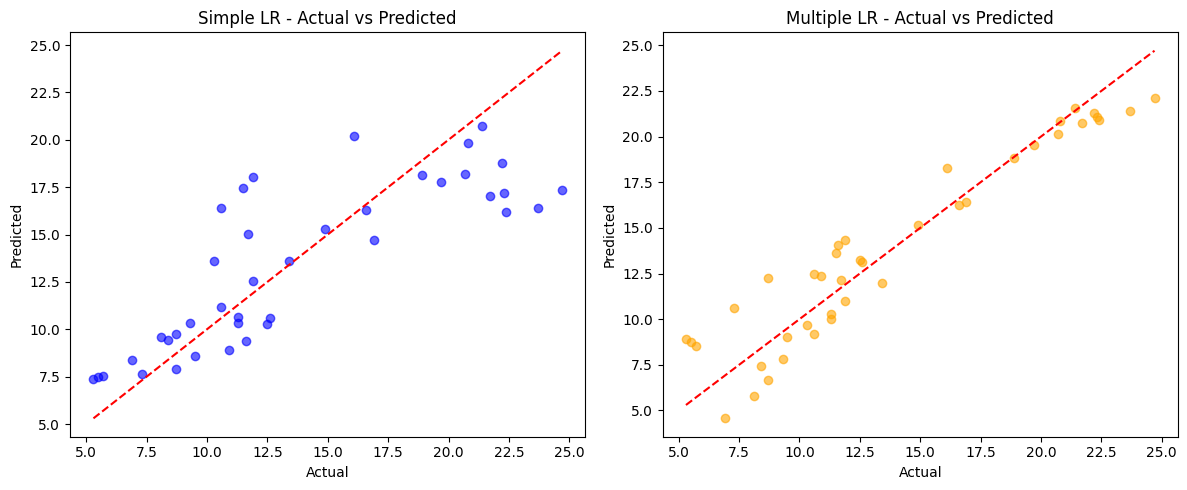

In [33]:
# ============================================================
#   LINEAR REGRESSION & MULTIPLE LINEAR REGRESSION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv("Advertising-multi_linear.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
print(df.head())

# ── SIMPLE LINEAR REGRESSION (TV → Sales) ──
X = df[["TV"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

slr = LinearRegression()
slr.fit(X_train, y_train)
y_pred = slr.predict(X_test)

print("\n--- Simple Linear Regression ---")
print(f"Coefficient : {slr.coef_[0]:.4f}")
print(f"Intercept   : {slr.intercept_:.4f}")
print(f"MSE         : {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2 Score    : {r2_score(y_test, y_pred):.4f}")

# ── MULTIPLE LINEAR REGRESSION (TV + Radio + Newspaper → Sales) ──
X_multi = df[["TV", "Radio", "Newspaper"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train_m, y_train_m)
y_pred_m = mlr.predict(X_test_m)

print("\n--- Multiple Linear Regression ---")
for name, coef in zip(X_multi.columns, mlr.coef_):
    print(f"{name} Coefficient: {coef:.4f}")
print(f"Intercept : {mlr.intercept_:.4f}")
print(f"MSE       : {mean_squared_error(y_test_m, y_pred_m):.4f}")
print(f"R2 Score  : {r2_score(y_test_m, y_pred_m):.4f}")

# ── PLOTS ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - Simple LR
axes[0].scatter(y_test, y_pred, color='blue', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Simple LR - Actual vs Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Plot 2 - Multiple LR
axes[1].scatter(y_test_m, y_pred_m, color='orange', alpha=0.6)
axes[1].plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--')
axes[1].set_title("Multiple LR - Actual vs Predicted")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()